In [1]:
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np

from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

from sv3.nn import SvenWrapper, MLP
from sv3.sven import Sven

import sys
sys.path.append('..')
import copy

from experiments.experiment_code.experiment_utils import train_loop_standard, train_loop_svd, set_seed

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [2]:
from torchvision import datasets, transforms
from experiments.datasets import MNISTDataset

digits = np.arange(10)
mnist = MNISTDataset(ROOT='./torch_datasets/',digits=digits)
train_dataset = mnist.train_dataset
test_dataset = mnist.val_dataset

In [3]:
set_seed(437438)
def get_model():
    return MLP(
        input_dim=784,
        hidden_dims=[32,32],
        output_dim=len(digits)
    )
mlp_base = get_model()
init_state = copy.deepcopy(mlp_base.state_dict())
del mlp_base # free memory

In [4]:
LOADER_SEED = 645297
batch_size = 64
n_epoch = 10
K = 64
RTOL = 1e-3
LR = 1e-3
LR_SVD = 0.5

### Train MLP with Adam

In [5]:
model_adam = get_model()
model_adam.load_state_dict(init_state)
model_adam = model_adam.to(device)

optimizer = torch.optim.Adam(model_adam.parameters(), lr=LR)
def loss_fn(pred,y):
    y = F.one_hot(y, num_classes=len(digits)).to(pred)
    return (pred - y).pow(2).sum(dim=1).mean()

train_loader = DataLoader(mnist.train_dataset, batch_size=batch_size, shuffle=True, generator=torch.Generator().manual_seed(LOADER_SEED))
test_loader = DataLoader(mnist.val_dataset, batch_size=256, shuffle=False)

model_adam, losses_adam = train_loop_standard(model_adam, optimizer, loss_fn, train_loader, test_loader, n_epoch, device, track_acc=True)

Using device cuda


100%|██████████| 10/10 [00:38<00:00,  3.89s/it]


### Train MLP with Sven

In [6]:
if device == torch.device('mps'):
    device = torch.device('cpu')
model_svd = get_model()
model_svd.load_state_dict(init_state)
model_svd = model_svd.to(device)

def loss_fn(pred,y):
    y = F.one_hot(y, num_classes=len(digits)).to(pred)
    return (pred - y).pow(2).sum(dim=1)


model_svd = SvenWrapper(model_svd, loss_fn, device=device)
optimizer = Sven(model_svd,lr=LR_SVD,k=K,rtol=RTOL,track_svd_info=True,svd_mode='torch', use_rmsprop=False)

train_loader = DataLoader(mnist.train_dataset, batch_size=batch_size, shuffle=True, generator=torch.Generator().manual_seed(LOADER_SEED))
test_loader = DataLoader(mnist.val_dataset, batch_size=256, shuffle=False)

model_svd, losses_svd, optimizer = train_loop_svd(model_svd,optimizer,loss_fn,train_loader,test_loader,n_epoch,device,track_acc=True)
svd_info = optimizer.svd_info

100%|██████████| 10/10 [02:02<00:00, 12.22s/it]


### train LBFGS

In [7]:
lr_lbfgs = 0.1
lbfgs_max_iter = 5
lbfgs_history_size = 2
lbfgs_line_search_fn = 'strong_wolfe'

model_lbfgs = get_model()
model_lbfgs.load_state_dict(init_state)
model_lbfgs = model_lbfgs.to(device)

# LBFGS needs a scalar loss; wrap per-sample loss with mean
def loss_fn_scalar(pred, y):
    y = F.one_hot(y, num_classes=len(digits)).to(pred)
    return (pred - y).pow(2).sum(dim=1).mean()

optimizer_lbfgs = torch.optim.LBFGS(
    model_lbfgs.parameters(),
    lr=lr_lbfgs,
    max_iter=lbfgs_max_iter,
    history_size=lbfgs_history_size,
    line_search_fn=lbfgs_line_search_fn,
)

train_loader = DataLoader(mnist.train_dataset, batch_size=batch_size, shuffle=True, generator=torch.Generator().manual_seed(LOADER_SEED))
test_loader = DataLoader(mnist.val_dataset, batch_size=256, shuffle=False)

model_lbfgs, losses_lbfgs = train_loop_standard(
    model_lbfgs, optimizer_lbfgs, loss_fn_scalar,
    train_loader, test_loader, n_epoch, device,
)

Using device cuda


100%|██████████| 10/10 [04:46<00:00, 28.64s/it]


### Train SGD with polyak step

In [ ]:
from sv3.sven import PolyakSGD

model_sgd = get_model()
model_sgd.load_state_dict(init_state)
model_sgd = model_sgd.to(device)

# LBFGS needs a scalar loss; wrap per-sample loss with mean
def loss_fn_scalar(pred, y):
    y = F.one_hot(y, num_classes=len(digits)).to(pred)
    return (pred - y).pow(2).sum(dim=1).mean()

optimizer_sgd = PolyakSGD(model_sgd.parameters())

train_loader = DataLoader(mnist.train_dataset, batch_size=batch_size, shuffle=True, generator=torch.Generator().manual_seed(LOADER_SEED))
test_loader = DataLoader(mnist.val_dataset, batch_size=256, shuffle=False)

model_sgd, losses_sgd = train_loop_standard(
    model_sgd, optimizer_sgd, loss_fn_scalar,
    train_loader, test_loader, n_epoch, device,
)

Using device cuda


100%|██████████| 10/10 [00:45<00:00,  4.50s/it]


### train sven with polyak step

In [9]:
if device == torch.device('mps'):
    device = torch.device('cpu')
model_svd_polyak = get_model()
model_svd_polyak.load_state_dict(init_state)
model_svd_polyak = model_svd_polyak.to(device)

def loss_fn(pred,y):
    y = F.one_hot(y, num_classes=len(digits)).to(pred)
    return (pred - y).pow(2).sum(dim=1)


model_svd_polyak = SvenWrapper(model_svd_polyak, loss_fn, device=device)
optimizer_polyak = Sven(model_svd_polyak,lr='polyak',k=K,rtol=RTOL,track_svd_info=True,svd_mode='torch', use_rmsprop=False)

train_loader = DataLoader(mnist.train_dataset, batch_size=batch_size, shuffle=True, generator=torch.Generator().manual_seed(LOADER_SEED))
test_loader = DataLoader(mnist.val_dataset, batch_size=256, shuffle=False)

model_svd_polyak, losses_svd_polyak, optimizer_polyak = train_loop_svd(model_svd_polyak,optimizer_polyak,loss_fn,train_loader,test_loader,n_epoch,device,track_acc=True)
svd_info = optimizer_polyak.svd_info

100%|██████████| 10/10 [02:11<00:00, 13.19s/it]


### compare all three

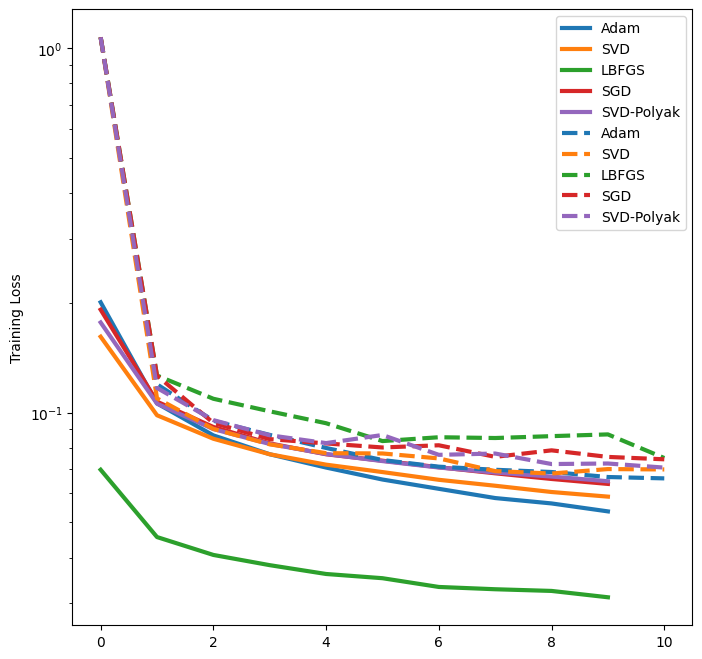

In [10]:
plt.figure(figsize=(8,8))
plt.plot(losses_adam['train'],label='Adam',lw=3)
plt.plot(losses_svd['train'],label='SVD',lw=3)
plt.plot(losses_lbfgs['train'],label='LBFGS',lw=3)
plt.plot(losses_sgd['train'],label='SGD',lw=3)
plt.plot(losses_svd_polyak['train'],label='SVD-Polyak',lw=3)

plt.plot(losses_adam['val'],label='Adam',lw=3,linestyle='--',color='C0')
plt.plot(losses_svd['val'],label='SVD',lw=3,linestyle='--',color='C1')
plt.plot(losses_lbfgs['val'],label='LBFGS',lw=3,linestyle='--',color='C2')
plt.plot(losses_sgd['val'],label='SGD',lw=3,linestyle='--',color='C3')
plt.plot(losses_svd_polyak['val'],label='SVD-Polyak',lw=3,linestyle='--',color='C4')
plt.legend()
plt.ylabel("Training Loss")
plt.yscale('log')

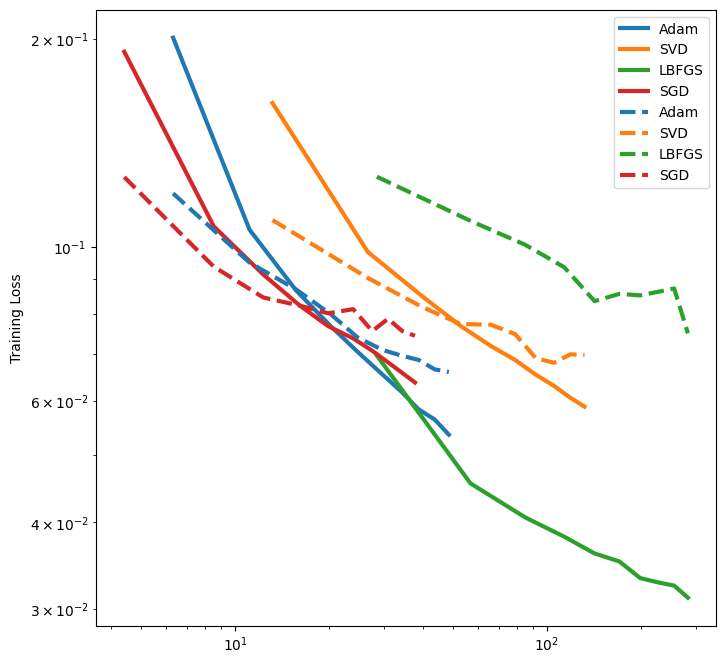

In [ ]:
plt.figure(figsize=(8,8))
times_adam = np.cumsum(losses_adam['epoch_times'])
times_svd = np.cumsum(losses_svd['epoch_times'])
times_lbfgs = np.cumsum(losses_lbfgs['epoch_times'])
times_sgd = np.cumsum(losses_sgd['epoch_times'])
times_svd_polyak = np.cumsum(losses_svd_polyak['epoch_times'])

plt.plot(times_adam, losses_adam['train'],label='Adam',lw=3)
plt.plot(times_svd, losses_svd['train'],label='SVD',lw=3)
plt.plot(times_lbfgs, losses_lbfgs['train'],label='LBFGS',lw=3)
plt.plot(times_sgd, losses_sgd['train'],label='SGD',lw=3)
plt.plot(times_svd_polyak, losses_svd_polyak['train'],label='SVD-Polyak',lw=3)

plt.plot(times_adam, losses_adam['val'][1:],label='Adam',lw=3,linestyle='--',color='C0')
plt.plot(times_svd, losses_svd['val'][1:],label='SVD',lw=3,linestyle='--',color='C1')
plt.plot(times_lbfgs, losses_lbfgs['val'][1:],label='LBFGS',lw=3,linestyle='--',color='C2')
plt.plot(times_sgd, losses_sgd['val'][1:],label='SGD',lw=3,linestyle='--',color='C3')
plt.plot(times_svd_polyak, losses_svd_polyak['val'][1:],label='SVD-Polyak',lw=3,linestyle='--',color='C4')
plt.legend()
plt.ylabel("Training Loss")
plt.yscale('log')
plt.xscale('log')

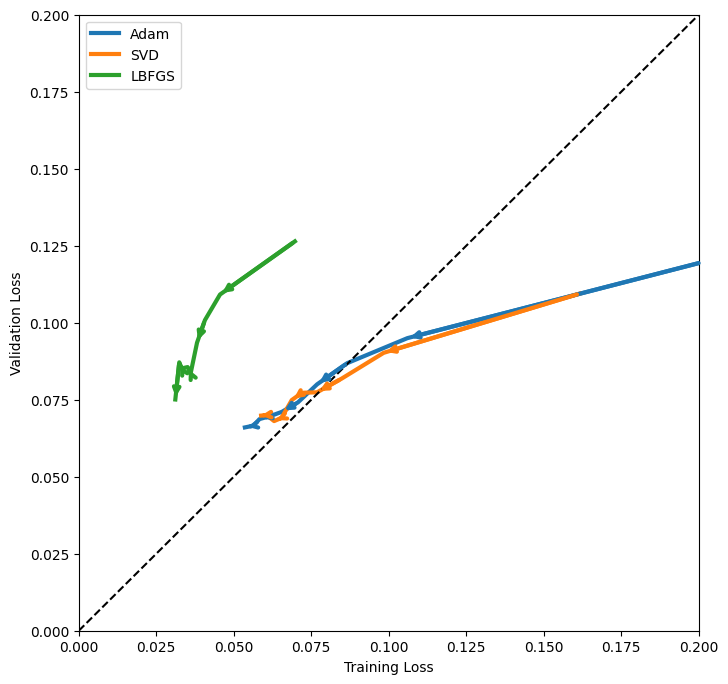

In [25]:

fig, ax = plt.subplots(figsize=(8,8))

def add_arrows(x, y, color, n_arrows=5, ax=None):
    if ax is None:
        ax = plt.gca()
    x, y = np.array(x), np.array(y)
    indices = np.linspace(0, len(x) - 2, n_arrows, dtype=int)
    for i in indices:
        ax.annotate('',
                    xy=(x[i+1], y[i+1]),
                    xytext=(x[i], y[i]),
                    arrowprops=dict(arrowstyle='->', color=color, lw=3))

ax.plot(losses_adam['train'], losses_adam['val'][1:], label='Adam', lw=3)
ax.plot(losses_svd['train'], losses_svd['val'][1:], label='SVD', lw=3)
ax.plot(losses_lbfgs['train'], losses_lbfgs['val'][1:], label='LBFGS', lw=3)

add_arrows(losses_adam['train'], losses_adam['val'][1:], 'C0', n_arrows=5, ax=ax)
add_arrows(losses_svd['train'], losses_svd['val'][1:], 'C1', n_arrows=5, ax=ax)
add_arrows(losses_lbfgs['train'], losses_lbfgs['val'][1:], 'C2', n_arrows=5, ax=ax)

ax.legend()
ax.set_xlabel("Training Loss")
ax.set_ylabel("Validation Loss")
ax.set_xlim([0, 0.2])
ax.set_ylim([0, 0.2])
ax.plot([0, 0.2], [0, 0.2], color='black', linestyle='--')
